In [1]:
"""Test: compare source and target train loader outputs under augmentation.

Checks whether augmentation introduces systematic feature differences between
MC (source) and exp (target) that would make domains artificially separable.
"""

import sys
from pathlib import Path
import numpy as np
import torch
import yaml

from src.data.prefilter_npy_dataset import (
    PrefilterNpyDataset,
    ExpDataset,
    create_prefilter_npy_dataloader,
)

# --- Config (match baseline) ---
def _load_normalization_config():
    stats_path = Path("data_manager") / "stats_dict" / "default_mc.yaml"
    if not stats_path.exists():
        print(f"Normalization stats not found: {stats_path}")
        return {"means": [0.0] * 5, "stds": [1.0] * 5}
    with open(stats_path) as f:
        cfg = yaml.safe_load(f)
    print(f"Loaded normalization config from {stats_path}")
    return cfg

CONFIG = {
    "npy_dir": "/home2/albert/Baikal/datasets/baikal_mc2020_prefilter/",
    "exp_h5": "data_manager/data/h5datasets/exp.h5",
    "max_hits": 500,
    "max_events": 5000,
    "batch_size": 1024,
    "seed": 42,
    "normalization": _load_normalization_config(),  # skip norm to see raw augmented values
    "augmentation": {
        "noise_std": [0.05, 5.0, 1.0, 1.0, 2.0],
        "rotation_enabled": False,
    },
}

FEATURE_NAMES = ["amplitude", "time", "x", "y", "z"]



def get_feature_stats(loader, n_batches=10, label=""):
    means = []
    stds = []
    for i, batch in enumerate(loader):
        if i >= n_batches:
            break
        feat = batch["features"]   # (B, L, 5)
        mask = batch["mask"]       # (B, L)
        # Flatten to (N_hits, 5) using mask
        flat = feat[mask]          # (N_valid_hits, 5)
        means.append(flat.mean(dim=0))
        stds.append(flat.std(dim=0))

    mean = torch.stack(means).mean(dim=0)
    std = torch.stack(stds).mean(dim=0)
    print(f"\n{label} feature stats (mean over {n_batches} batches):")
    for i, name in enumerate(FEATURE_NAMES):
        print(f"  {name:12s}: mean={mean[i]:8.3f}  std={std[i]:8.3f}")
    return mean, std

Loaded normalization config from data_manager/stats_dict/default_mc.yaml


In [2]:
print("Loading source dataset (MC NPY)...")
src_ds = PrefilterNpyDataset(
    npy_dir=CONFIG["npy_dir"],
    max_hits=CONFIG["max_hits"],
    max_events=CONFIG["max_events"],
    seed=CONFIG["seed"],
)
src_train, _ = src_ds.split(0.85, seed=CONFIG["seed"])
# Filter to muatm only (particle_type == 0)
mu_mask = src_train.particle_types[src_train._indices] == 0
src_train._indices = src_train._indices[mu_mask]
print(f"  Muon-only source train: {len(src_train):,} events")


print("Loading target dataset (exp.h5)...")
tgt_ds = ExpDataset(
    h5_path=CONFIG["exp_h5"],
    max_hits=CONFIG["max_hits"],
    max_events=CONFIG["max_events"],
    seed=CONFIG["seed"],
)
tgt_train, _ = tgt_ds.split(0.85, seed=CONFIG["seed"])

# --- With augmentation ---
src_aug_loader = create_prefilter_npy_dataloader(
    src_train, CONFIG["batch_size"], shuffle=False,
    normalization_config=CONFIG["normalization"],
    augmentation_config=CONFIG["augmentation"],
    shuffle_batch=False, device="cpu",
)
tgt_aug_loader = create_prefilter_npy_dataloader(
    tgt_train, CONFIG["batch_size"], shuffle=False,
    normalization_config=CONFIG["normalization"],
    augmentation_config=CONFIG["augmentation"],
    shuffle_batch=False, device="cpu",
)

# --- Without augmentation ---
src_noaug_loader = create_prefilter_npy_dataloader(
    src_train, CONFIG["batch_size"], shuffle=False,
    normalization_config=CONFIG["normalization"],
    augmentation_config=None,
    shuffle_batch=False, device="cpu",
)
tgt_noaug_loader = create_prefilter_npy_dataloader(
    tgt_train, CONFIG["batch_size"], shuffle=False,
    normalization_config=CONFIG["normalization"],
    augmentation_config=None,
    shuffle_batch=False, device="cpu",
)

N = 20
src_mean_aug, src_std_aug   = get_feature_stats(src_aug_loader,   N, "SOURCE  (aug)")
tgt_mean_aug, tgt_std_aug   = get_feature_stats(tgt_aug_loader,   N, "TARGET  (aug)")
src_mean_raw, src_std_raw   = get_feature_stats(src_noaug_loader, N, "SOURCE  (raw)")
tgt_mean_raw, tgt_std_raw   = get_feature_stats(tgt_noaug_loader, N, "TARGET  (raw)")

print("\n--- Mean difference (source - target) ---")
print(f"{'feature':12s}  {'aug':>10s}  {'raw':>10s}  {'aug/raw ratio':>14s}")
for i, name in enumerate(FEATURE_NAMES):
    diff_aug = (src_mean_aug[i] - tgt_mean_aug[i]).abs().item()
    diff_raw = (src_mean_raw[i] - tgt_mean_raw[i]).abs().item()
    ratio = diff_aug / (diff_raw + 1e-8)
    print(f"  {name:12s}  {diff_aug:10.4f}  {diff_raw:10.4f}  {ratio:14.2f}x")

print("\n--- Std difference (source - target) ---")
print(f"{'feature':12s}  {'aug':>10s}  {'raw':>10s}  {'aug/raw ratio':>14s}")
for i, name in enumerate(FEATURE_NAMES):
    diff_aug = (src_std_aug[i] - tgt_std_aug[i]).abs().item()
    diff_raw = (src_std_raw[i] - tgt_std_raw[i]).abs().item()
    ratio = diff_aug / (diff_raw + 1e-8)
    print(f"  {name:12s}  {diff_aug:10.4f}  {diff_raw:10.4f}  {ratio:14.2f}x")


Loading source dataset (MC NPY)...
  Muon-only source train: 1,570 events
Loading target dataset (exp.h5)...

SOURCE  (aug) feature stats (mean over 20 batches):
  amplitude   : mean=  -0.011  std=   0.163
  time        : mean=  -0.000  std=   1.005
  x           : mean=   0.021  std=   1.000
  y           : mean=   0.012  std=   0.973
  z           : mean=   0.253  std=   1.028

TARGET  (aug) feature stats (mean over 20 batches):
  amplitude   : mean=  -0.010  std=   0.166
  time        : mean=  -0.000  std=   1.033
  x           : mean=   0.023  std=   0.990
  y           : mean=   0.039  std=   0.948
  z           : mean=   0.251  std=   1.036

SOURCE  (raw) feature stats (mean over 20 batches):
  amplitude   : mean=  -0.011  std=   0.163
  time        : mean=   0.000  std=   1.005
  x           : mean=   0.021  std=   0.999
  y           : mean=   0.012  std=   0.973
  z           : mean=   0.253  std=   1.028

TARGET  (raw) feature stats (mean over 20 batches):
  amplitude   : mea

In [3]:
import matplotlib.pyplot as plt

event_idx = 10# slice(0,10)

for batch in src_aug_loader:
    x_src_aug = batch['features'][event_idx,:,2].flatten()
    y_src_aug = batch['features'][event_idx,:,3].flatten()
    break

for batch in src_noaug_loader:
    x_src_raw = batch['features'][event_idx,:,2].flatten()
    y_src_raw = batch['features'][event_idx,:,3].flatten()
    break

for batch in tgt_aug_loader:
    x_tgt_aug = batch['features'][event_idx,:,2].flatten()
    y_tgt_aug = batch['features'][event_idx,:,3].flatten()
    break

for batch in tgt_noaug_loader:
    x_tgt_raw = batch['features'][event_idx,:,2].flatten()
    y_tgt_raw = batch['features'][event_idx,:,3].flatten()
    break

In [4]:
for batch in src_aug_loader:
    print(batch['features'][0,:,1])
    break

for batch in src_noaug_loader:
    print(batch['features'][0,:,1])
    break

tensor([-1.7101, -1.6390, -1.5835, -1.5476, -1.5258, -1.5213, -1.2963, -1.2761,
        -1.2110, -1.2085, -1.2059, -1.2032, -1.1148, -1.1000, -1.0992, -0.9523,
        -0.8574, -0.8547, -0.8208, -0.8182, -0.7901, -0.7664, -0.7486, -0.7390,
        -0.7236, -0.7222, -0.7152, -0.5752, -0.5275, -0.4950, -0.4668, -0.4434,
        -0.4307, -0.4286, -0.4150, -0.3717, -0.3049, -0.2934, -0.2007, -0.1364,
        -0.1336, -0.0914, -0.0723, -0.0542, -0.0469, -0.0468, -0.0390, -0.0385,
        -0.0240, -0.0115,  0.0196,  0.0453,  0.0522,  0.0902,  0.1187,  0.1217,
         0.1312,  0.1501,  0.1846,  0.2734,  0.2916,  0.3509,  0.3598,  0.3704,
         0.3844,  0.3875,  0.4075,  0.4917,  0.5745,  0.5756,  0.6414,  0.6501,
         0.6560,  0.6624,  0.6930,  0.7686,  0.7810,  0.7837,  0.8334,  0.9450,
         0.9541,  1.1056,  1.1096,  1.3077,  1.3307,  1.3351,  1.3528,  1.3544,
         1.3994,  1.4672,  1.4809,  1.5683,  1.5862,  1.6260,  1.7377,  1.8715,
         0.0000,  0.0000,  0.0000,  0.00

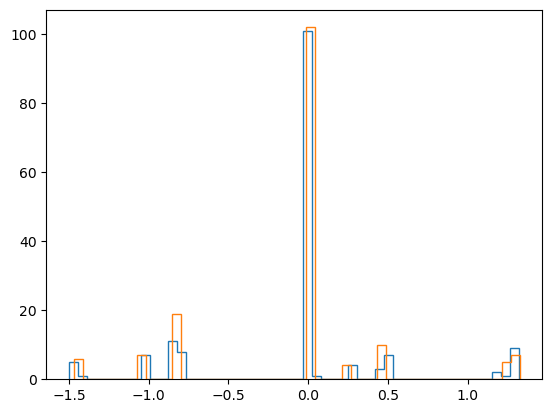

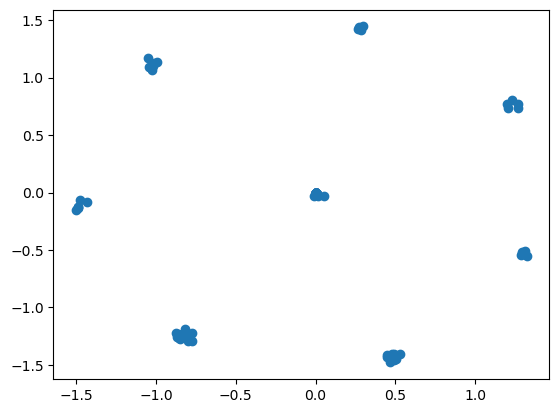

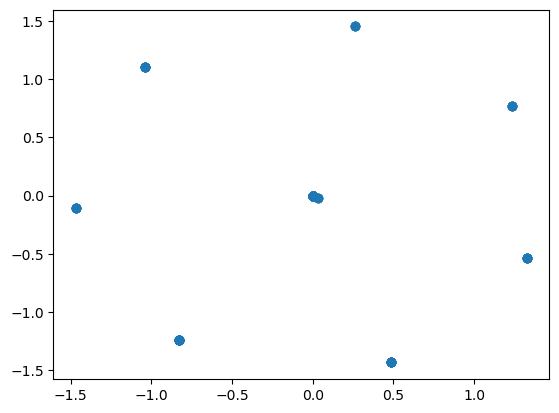

In [5]:
plt.hist(x_src_aug, histtype='step', bins=50)
plt.hist(x_src_raw, histtype='step', bins=50)
plt.show()

plt.scatter(x_src_aug, y_src_aug)
plt.show()
plt.scatter(x_src_raw, y_src_raw)
plt.show()

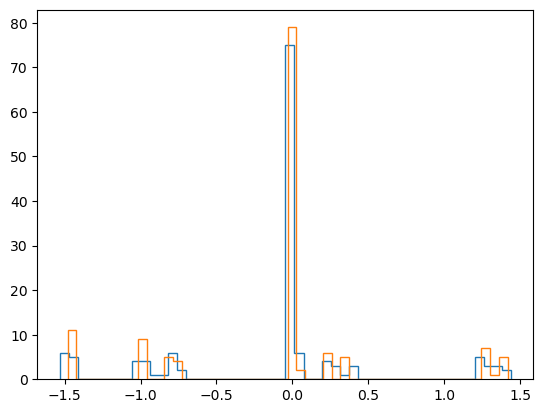

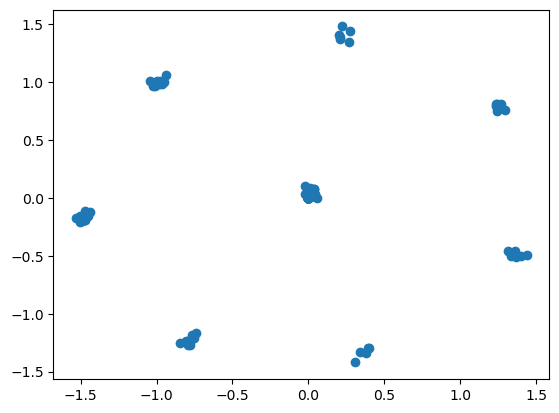

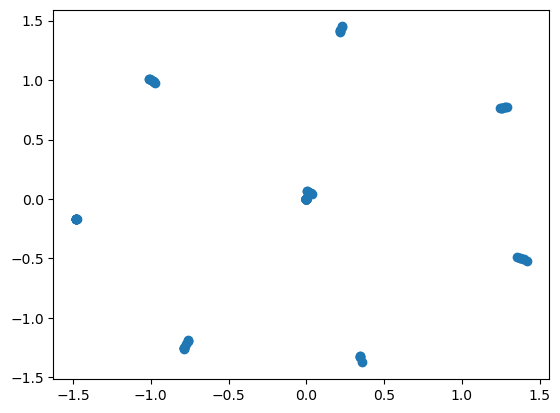

In [6]:
import matplotlib.pyplot as plt


plt.hist(x_tgt_aug, histtype='step', bins=50)
plt.hist(x_tgt_raw, histtype='step', bins=50)
plt.show()

plt.scatter(x_tgt_aug, y_tgt_aug)
plt.show()
plt.scatter(x_tgt_raw, y_tgt_raw)
plt.show()

In [8]:
batch['features'][batch['mask']].shape

torch.Size([19663, 5])